
# Experiment results analysis

This notebook loads the final CSV summaries produced by the existing notebooks so that we can analyze them.


In [2]:
from src.result_analysis_plots import *
from src.constants import *
import json

# You can keep exact file names or patterns with * ("top_side_frozen_lovo_*.csv") to automatically pick the latest matching file
RESULT_FILE_SPECS = {
    "top_side_performance": "top_side_frozen_performance_FINAL.csv",
    "only_top_performance": "only_top_frozen_performance_FINAL.csv",
    "only_side_performance": "only_side_frozen_performance_FINAL.csv",
    "top_side_lovo": "top_side_frozen_lovo_FINAL.csv",
    "last_stage_unfrozen_performance": "last_stage_unfrozen_performance_FINAL.csv"
}

OOF_FILE_SPECS = {
    "top_side_performance": "top_side_frozen_performance_oof_predictions_FINAL.csv",
    "only_top_performance": "only_top_frozen_performance_oof_predictions_FINAL.csv",
    "only_side_performance": "only_side_frozen_performance_oof_predictions_FINAL.csv",
    "top_side_lovo": "top_side_frozen_lovo_oof_predictions_FINAL.csv",
    "last_stage_unfrozen": "last_stage_unfrozen_oof_predictions_FINAL.csv"
}

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

/home/lenka-hake/Documents/CV/ComputerVisionProject/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Load Results

In [3]:
top_side_performance_df = load_result_csv(
    resolve_result_file(RESULT_FILE_SPECS["top_side_performance"], results_dir=OUTPUT_DIR),
    experiment_name="top_side_performance", results_dir=OUTPUT_DIR)

only_top_performance_df = load_result_csv(
    resolve_result_file(RESULT_FILE_SPECS["only_top_performance"], results_dir=OUTPUT_DIR),
    experiment_name="only_top_performance", results_dir=OUTPUT_DIR)

only_side_performance_df = load_result_csv(
    resolve_result_file(RESULT_FILE_SPECS["only_side_performance"], results_dir=OUTPUT_DIR),
    experiment_name="only_side_performance", results_dir=OUTPUT_DIR)

top_side_lovo_df = load_result_csv(
    resolve_result_file(RESULT_FILE_SPECS["top_side_lovo"], results_dir=OUTPUT_DIR),
    experiment_name="top_side_lovo", results_dir=OUTPUT_DIR)

last_stage_unfrozen_df = load_result_csv(
    resolve_result_file(RESULT_FILE_SPECS["last_stage_unfrozen_performance"], results_dir=OUTPUT_DIR),
    experiment_name="last_stage_unfrozen", results_dir=OUTPUT_DIR
)

top_side_performance_oof_df = pd.read_csv(resolve_result_file(OOF_FILE_SPECS["top_side_performance"], results_dir=OUTPUT_DIR))
only_top_performance_oof_df = pd.read_csv(resolve_result_file(OOF_FILE_SPECS["only_top_performance"], results_dir=OUTPUT_DIR))
only_side_performance_oof_df = pd.read_csv(resolve_result_file(OOF_FILE_SPECS["only_side_performance"], results_dir=OUTPUT_DIR))
top_side_lovo_oof_df = pd.read_csv(resolve_result_file(OOF_FILE_SPECS["top_side_lovo"], results_dir=OUTPUT_DIR))
last_stage_unfrozen_oof_df = pd.read_csv(resolve_result_file(OOF_FILE_SPECS["last_stage_unfrozen"], results_dir=OUTPUT_DIR))

resolved_files = {
    "top_side_performance": resolve_result_file(RESULT_FILE_SPECS["top_side_performance"], results_dir=OUTPUT_DIR),
    "only_top_performance": resolve_result_file(RESULT_FILE_SPECS["only_top_performance"], results_dir=OUTPUT_DIR),
    "only_side_performance": resolve_result_file(RESULT_FILE_SPECS["only_side_performance"], results_dir=OUTPUT_DIR),
    "top_side_lovo": resolve_result_file(RESULT_FILE_SPECS["top_side_lovo"], results_dir=OUTPUT_DIR),
    "last_stage_unfrozen": resolve_result_file(RESULT_FILE_SPECS["last_stage_unfrozen_performance"], results_dir=OUTPUT_DIR),
}

resolved_oof_files = {
    "top_side_performance": resolve_result_file(OOF_FILE_SPECS["top_side_performance"], results_dir=OUTPUT_DIR),
    "only_top_performance": resolve_result_file(OOF_FILE_SPECS["only_top_performance"], results_dir=OUTPUT_DIR),
    "only_side_performance": resolve_result_file(OOF_FILE_SPECS["only_side_performance"], results_dir=OUTPUT_DIR),
    "top_side_lovo": resolve_result_file(OOF_FILE_SPECS["top_side_lovo"], results_dir=OUTPUT_DIR),
    "last_stage_unfrozen": resolve_result_file(OOF_FILE_SPECS["last_stage_unfrozen"], results_dir=OUTPUT_DIR),
}

print("Resolved files:")
for key, path in resolved_files.items():
    print(f"  {key}: {path}")

print()
print("Resolved OOF files:")
for key, path in resolved_oof_files.items():
    print(f"  {key}: {path}")

print()
print("Shapes:")
print("  top_side_performance_df:", top_side_performance_df.shape)
print("  only_top_performance_df:", only_top_performance_df.shape)
print("  only_side_performance_df:", only_side_performance_df.shape)
print("  top_side_lovo_df:", top_side_lovo_df.shape)
print("  last_stage_unfrozen_df:", last_stage_unfrozen_df.shape)
print()
print("OOF shapes:")
print("  top_side_performance_oof_df:", top_side_performance_oof_df.shape)
print("  only_top_performance_oof_df:", only_top_performance_oof_df.shape)
print("  only_side_performance_oof_df:", only_side_performance_oof_df.shape)
print("  top_side_lovo_oof_df:", top_side_lovo_oof_df.shape)
print("  last_stage_unfrozen_oof_df:", last_stage_unfrozen_oof_df.shape)

Resolved files:
  top_side_performance: results/top_side_frozen_performance_FINAL.csv
  only_top_performance: results/only_top_frozen_performance_FINAL.csv
  only_side_performance: results/only_side_frozen_performance_FINAL.csv
  top_side_lovo: results/top_side_frozen_lovo_FINAL.csv
  last_stage_unfrozen: results/last_stage_unfrozen_performance_FINAL.csv

Resolved OOF files:
  top_side_performance: results/top_side_frozen_performance_oof_predictions_FINAL.csv
  only_top_performance: results/only_top_frozen_performance_oof_predictions_FINAL.csv
  only_side_performance: results/only_side_frozen_performance_oof_predictions_FINAL.csv
  top_side_lovo: results/top_side_frozen_lovo_oof_predictions_FINAL.csv
  last_stage_unfrozen: results/last_stage_unfrozen_oof_predictions_FINAL.csv

Shapes:
  top_side_performance_df: (81, 12)
  only_top_performance_df: (4, 12)
  only_side_performance_df: (4, 12)
  top_side_lovo_df: (6, 12)
  last_stage_unfrozen_df: (5, 12)

OOF shapes:
  top_side_performance

# Some Examples

## Top Results

In [4]:
show_top(last_stage_unfrozen_df, n=10, metric="cv_mae_mean")

,backbone,fusion,regressor,cv_mae_mean,cv_rmse_mean,cv_r2_mean
0,vit_b_16,concat,mlp,0.2917,0.3822,0.8968
1,vit_b_16,concat,linear,0.3020,0.4059,0.8837
2,densenet121,concat,mlp,0.3595,0.4501,0.8574
3,densenet121,concat,linear,0.4473,0.5387,0.7883
4,dummy_mean,dummy_mean,dummy_mean,1.0614,1.1932,0.0000


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,experiment
0,vit_b_16,concat,mlp,0.2917,0.0248,0.1470,0.0234,0.3822,0.0307,0.8968,0.0160,last_stage_unfrozen
1,vit_b_16,concat,linear,0.3020,0.0173,0.1652,0.0154,0.4059,0.0190,0.8837,0.0124,last_stage_unfrozen
2,densenet121,concat,mlp,0.3595,0.0132,0.2027,0.0082,0.4501,0.0091,0.8574,0.0088,last_stage_unfrozen
3,densenet121,concat,linear,0.4473,0.0891,0.3001,0.1100,0.5387,0.0993,0.7883,0.0789,last_stage_unfrozen
4,dummy_mean,dummy_mean,dummy_mean,1.0614,0.0000,1.4238,0.0000,1.1932,0.0000,0.0000,0.0000,last_stage_unfrozen


## Comparison for Different Backbones, Fusion Methods, and Regressors

,backbone,best_mae,mean_mae,median_mae,best_rmse,mean_rmse,best_r2,mean_r2,top_10_count
0,densenet121,0.2581,0.3685,0.2987,0.3297,0.4668,0.9215,0.8224,10
1,convnext_tiny,0.2964,0.3903,0.3513,0.3748,0.4889,0.9008,0.8183,0
2,resnet50,0.3291,0.4699,0.3464,0.4175,0.5914,0.8759,0.6901,0
3,vit_b_16,0.3330,0.4302,0.3962,0.4229,0.5390,0.8739,0.7811,0
4,dummy_mean,1.0614,1.0614,1.0614,1.1932,1.1932,0.0000,0.0000,0


,fusion,best_mae,mean_mae,median_mae,best_rmse,mean_rmse,best_r2,mean_r2,top_10_count
0,concat,0.2581,0.4195,0.3499,0.3297,0.5293,0.9215,0.7619,3
1,concat_abs_diff,0.2672,0.4168,0.3447,0.3415,0.5245,0.9160,0.7662,3
2,mean,0.2842,0.4050,0.3557,0.3637,0.5076,0.9049,0.7998,2
3,max,0.2862,0.4177,0.3596,0.3660,0.5248,0.9043,0.7841,2
4,dummy_mean,1.0614,1.0614,1.0614,1.1932,1.1932,0.0000,0.0000,0


,regressor,best_mae,mean_mae,median_mae,best_rmse,mean_rmse,best_r2,mean_r2,top_10_count
0,ridge,0.2581,0.3140,0.3245,0.3297,0.3994,0.9215,0.8853,4
1,linear,0.2657,0.3409,0.3405,0.3408,0.4312,0.9164,0.8657,2
2,elasticnet,0.2661,0.3193,0.3328,0.3386,0.4041,0.9173,0.8826,4
3,random_forest,0.3517,0.4069,0.4142,0.4391,0.4999,0.8637,0.8225,0
4,mlp,0.5080,0.6926,0.6420,0.6307,0.8732,0.7196,0.4338,0
5,dummy_mean,1.0614,1.0614,1.0614,1.1932,1.1932,0.0000,0.0000,0


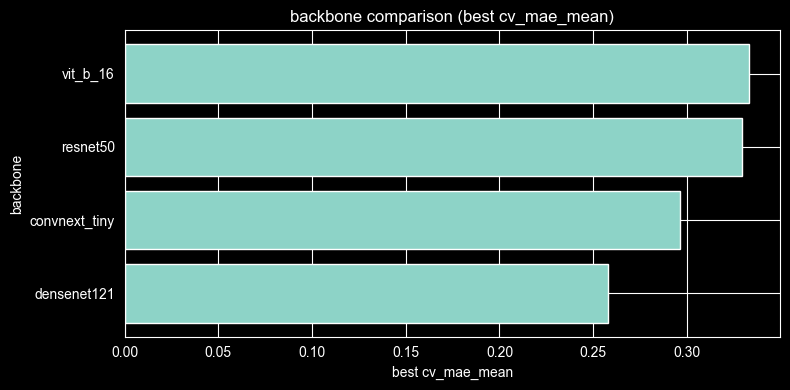

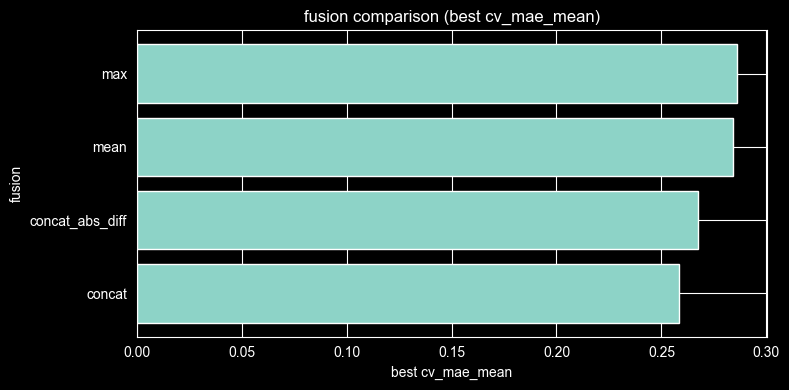

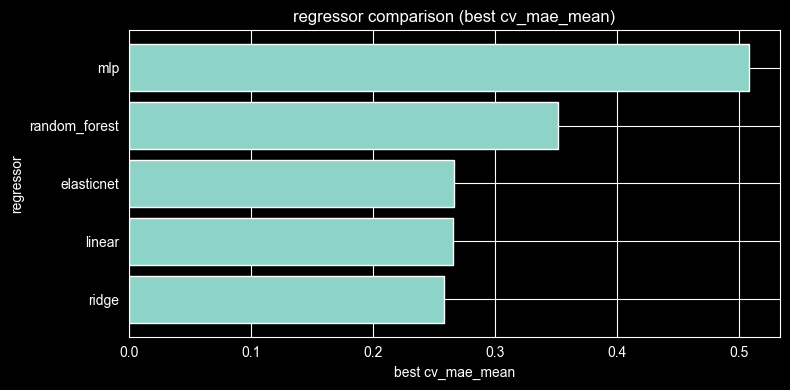

In [4]:
display(summarize_by(top_side_performance_df, "backbone"))
display(summarize_by(top_side_performance_df, "fusion"))
display(summarize_by(top_side_performance_df, "regressor"))

excluding_dummy = top_side_performance_df.head(len(top_side_performance_df) - 1)
plot_group_summary(excluding_dummy, "backbone", metric="cv_mae_mean", agg="best")
plot_group_summary(excluding_dummy, "fusion", metric="cv_mae_mean", agg="best")
plot_group_summary(excluding_dummy, "regressor", metric="cv_mae_mean", agg="best")

## Pairwise Heatmaps

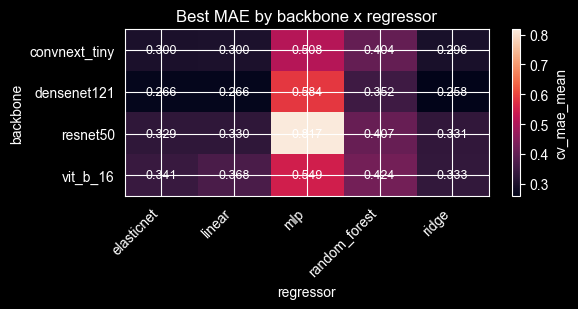

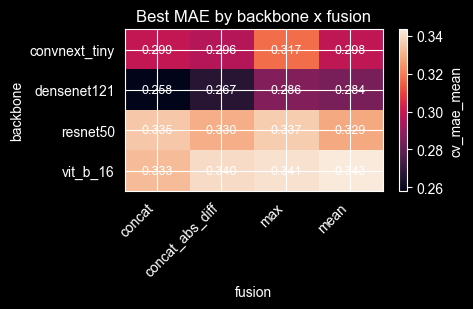

In [5]:
excluding_dummy = top_side_performance_df.head(len(top_side_performance_df) - 1)

plot_pairwise_heatmap(
    filter_results(excluding_dummy),
    row_col="backbone",
    col_col="regressor",
    metric="cv_mae_mean",
    agg="min",
    title="Best MAE by backbone x regressor",
)

plot_pairwise_heatmap(
    filter_results(excluding_dummy),
    row_col="backbone",
    col_col="fusion",
    metric="cv_mae_mean",
    agg="min",
    title="Best MAE by backbone x fusion",
)

## Results for DenseNet121

In [6]:
subset_df = filter_results(
    top_side_performance_df,
    experiments=None,
    backbones=["densenet121"],
    fusions=None,
    regressors=None,
)

show_top(subset_df, n=20, metric="cv_mae_mean")

,backbone,fusion,regressor,cv_mae_mean,cv_rmse_mean,cv_r2_mean
0,densenet121,concat,ridge,0.2581,0.3297,0.9215
1,densenet121,concat,linear,0.2657,0.3408,0.9164
2,densenet121,concat,elasticnet,0.2661,0.3386,0.9173
3,densenet121,concat_abs_diff,ridge,0.2672,0.3415,0.9160
4,densenet121,concat_abs_diff,linear,0.2712,0.3453,0.9141
5,densenet121,concat_abs_diff,elasticnet,0.2740,0.3466,0.9133
6,densenet121,mean,ridge,0.2842,0.3637,0.9049
7,densenet121,max,ridge,0.2862,0.3660,0.9043
8,densenet121,max,elasticnet,0.2884,0.3712,0.9001
9,densenet121,mean,elasticnet,0.2912,0.3744,0.8980


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,experiment
0,densenet121,concat,ridge,0.2581,0.0352,0.1108,0.0325,0.3297,0.0463,0.9215,0.0255,top_side_performance
1,densenet121,concat,linear,0.2657,0.0334,0.1181,0.0319,0.3408,0.0446,0.9164,0.0251,top_side_performance
2,densenet121,concat,elasticnet,0.2661,0.0390,0.1170,0.0336,0.3386,0.0481,0.9173,0.0261,top_side_performance
3,densenet121,concat_abs_diff,ridge,0.2672,0.0357,0.1186,0.0322,0.3415,0.0447,0.9160,0.0256,top_side_performance
4,densenet121,concat_abs_diff,linear,0.2712,0.0344,0.1213,0.0332,0.3453,0.0460,0.9141,0.0262,top_side_performance
5,densenet121,concat_abs_diff,elasticnet,0.2740,0.0411,0.1226,0.0352,0.3466,0.0493,0.9133,0.0274,top_side_performance
6,densenet121,mean,ridge,0.2842,0.0390,0.1345,0.0365,0.3637,0.0470,0.9049,0.0289,top_side_performance
7,densenet121,max,ridge,0.2862,0.0287,0.1354,0.0287,0.3660,0.0379,0.9043,0.0230,top_side_performance
8,densenet121,max,elasticnet,0.2884,0.0511,0.1410,0.0454,0.3712,0.0563,0.9001,0.0356,top_side_performance
9,densenet121,mean,elasticnet,0.2912,0.0475,0.1437,0.0496,0.3744,0.0597,0.8980,0.0390,top_side_performance


## Top-View vs. Side-View vs. Multi-View Overall Performance

                          mean    std
Experiment                           
Multi-View\n(Ridge)     0.2581 0.0394
Side Only\n(Elasticnet) 0.3860 0.0308
Top Only\n(Ridge)       0.2904 0.0456
Mean MAE: 0.31 +/- 0.04


C:\Users\sebas\PycharmProjects\Debris_Estimation\ComputerVisionProject\src\result_analysis_plots.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="Experiment", y=metric, data=df,


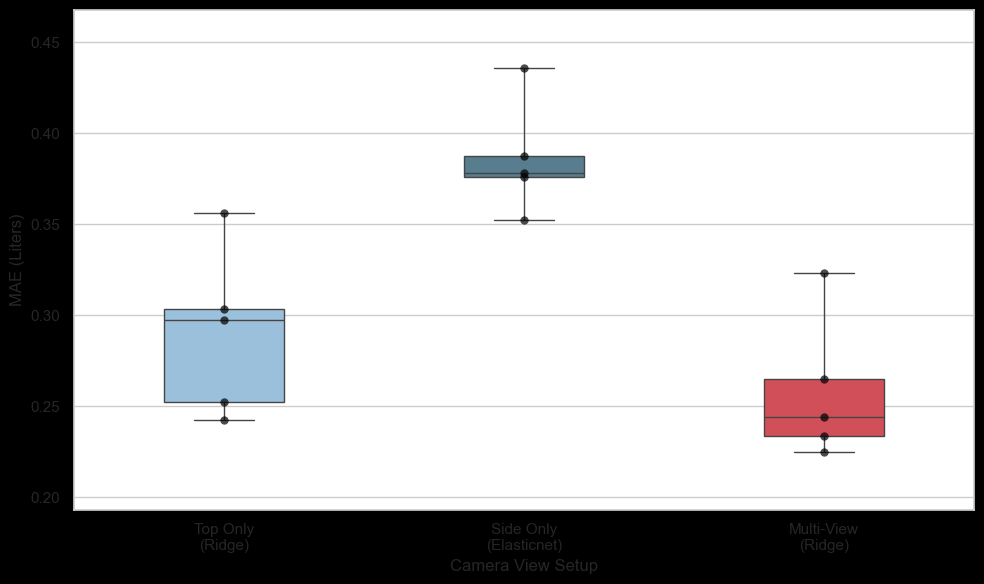

In [7]:
with open("results/only_top_frozen_performance_best_hyperparameters_FINAL.json", "r") as f:
    top_view = json.load(f)
with open("results/only_side_frozen_performance_best_hyperparameters_FINAL.json", "r") as f:
    side_view = json.load(f)
with open("results/top_side_frozen_performance_best_hyperparameters_FINAL.json", "r") as f:
    multi_view = json.load(f)
combined_views = {
    'densenet121__top only': top_view['densenet121__top only'],
    'densenet121__side only': side_view['densenet121__side only'],
    'densenet121__multi-view': multi_view['densenet121__concat']
}
plot_combined_best_methods(combined_views, metric="MAE")




## True vs Predicted Volume Plots for Best Configurations

Experiment: Multi-view (top 1 models)


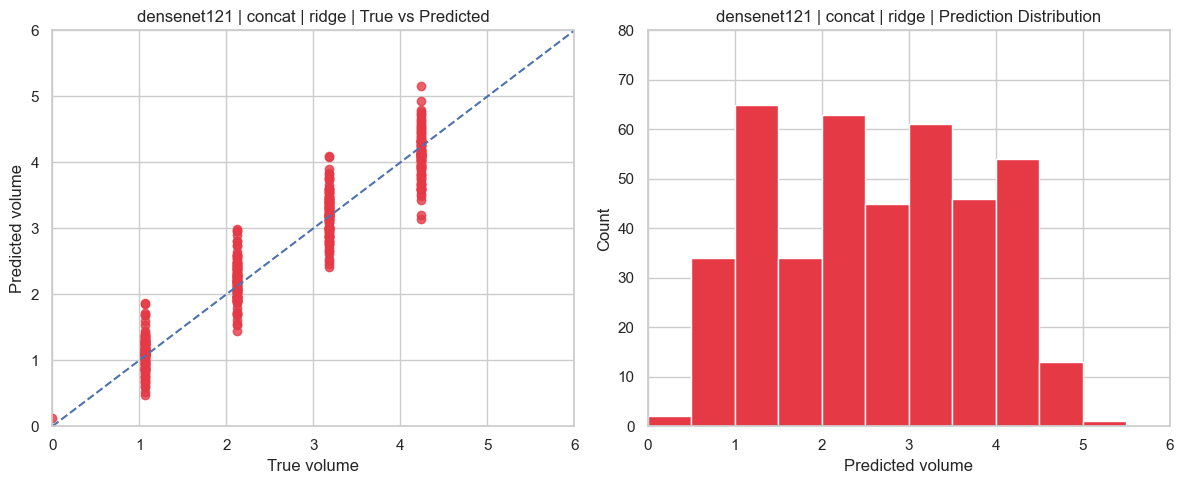

In [8]:
plot_best_oof_predictions(top_side_performance_df, top_side_performance_oof_df, "Multi-view", top_n=1, color="#E63946")